## NDTA631 Data Analysis and Visualization


Project Title: Exploring the Relationship Between Employment and Freedom in South Africa Datasets

Dataset 1: WB_AFS (Labour Force Statistics)

Dataset 2: FH_FIW (Freedom in the World)




The objective of this project is to investigate whether changes in South Africa's
political and civil freedom are associated with changes in labour-force
participation and employment.



## Question 1 : Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [36]:
import pandas as pd

folder = r"C:\Users\Admin\OneDrive - Sol Plaatje University\Desktop\NDTA63_Data"

employment = pd.read_csv(
    folder + r"\Employment in Agrifood System (AFS) Dataset 1.csv",
    low_memory=False
)

freedom = pd.read_csv(
    folder + r"\Freedom in the World Dataset 2.csv",
    low_memory=False
)

print("Employment Dataset:", employment.shape)
print("Freedom Dataset:", freedom.shape)

Employment Dataset: (4287, 41)
Freedom Dataset: (94240, 41)


In [37]:
freedom.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,TZA,FH_FIW_F2,_Z,_Z,_Z,0_TO_4,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Zero,Freedom in the World,CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,THA,FH_FIW_F2,_Z,_Z,_Z,0_TO_4,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Zero,Freedom in the World,CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,GMB,FH_FIW_F2,_Z,_Z,_Z,0_TO_4,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Zero,Freedom in the World,CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,TLS,FH_FIW_F2,_Z,_Z,_Z,0_TO_4,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Zero,Freedom in the World,CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,TGO,FH_FIW_F2,_Z,_Z,_Z,0_TO_4,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Zero,Freedom in the World,CCYY,Units,Normal value,Public


In [38]:
employment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4287 entries, 0 to 4286
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               4287 non-null   object 
 1   STRUCTURE_ID            4287 non-null   object 
 2   ACTION                  4287 non-null   object 
 3   FREQ                    4287 non-null   object 
 4   REF_AREA                4287 non-null   object 
 5   INDICATOR               4287 non-null   object 
 6   SEX                     4287 non-null   object 
 7   AGE                     4287 non-null   object 
 8   URBANISATION            4287 non-null   object 
 9   UNIT_MEASURE            4287 non-null   object 
 10  COMP_BREAKDOWN_1        4287 non-null   object 
 11  COMP_BREAKDOWN_2        4287 non-null   object 
 12  COMP_BREAKDOWN_3        4287 non-null   object 
 13  TIME_PERIOD             4287 non-null   int64  
 14  OBS_VALUE               4213 non-null   

In [39]:
freedom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94240 entries, 0 to 94239
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   STRUCTURE               94240 non-null  object
 1   STRUCTURE_ID            94240 non-null  object
 2   ACTION                  94240 non-null  object
 3   FREQ                    94240 non-null  object
 4   REF_AREA                94240 non-null  object
 5   INDICATOR               94240 non-null  object
 6   SEX                     94240 non-null  object
 7   AGE                     94240 non-null  object
 8   URBANISATION            94240 non-null  object
 9   UNIT_MEASURE            94240 non-null  object
 10  COMP_BREAKDOWN_1        94240 non-null  object
 11  COMP_BREAKDOWN_2        94240 non-null  object
 12  COMP_BREAKDOWN_3        94240 non-null  object
 13  TIME_PERIOD             94240 non-null  int64 
 14  OBS_VALUE               92868 non-null  object
 15  AG

In [40]:
employment.isnull().sum()

STRUCTURE                  0
STRUCTURE_ID               0
ACTION                     0
FREQ                       0
REF_AREA                   0
INDICATOR                  0
SEX                        0
AGE                        0
URBANISATION               0
UNIT_MEASURE               0
COMP_BREAKDOWN_1           0
COMP_BREAKDOWN_2           0
COMP_BREAKDOWN_3           0
TIME_PERIOD                0
OBS_VALUE                 74
AGG_METHOD                 0
UNIT_TYPE                  0
DECIMALS                   0
DATABASE_ID                0
TIME_FORMAT                0
UNIT_MULT                  0
OBS_STATUS                 0
OBS_CONF                   0
FREQ_LABEL                 0
REF_AREA_LABEL             0
INDICATOR_LABEL            0
SEX_LABEL                  0
AGE_LABEL                  0
URBANISATION_LABEL         0
UNIT_MEASURE_LABEL         0
COMP_BREAKDOWN_1_LABEL     0
COMP_BREAKDOWN_2_LABEL     0
COMP_BREAKDOWN_3_LABEL     0
AGG_METHOD_LABEL           0
UNIT_TYPE_LABE

In [41]:
freedom.isnull().sum()

STRUCTURE                    0
STRUCTURE_ID                 0
ACTION                       0
FREQ                         0
REF_AREA                     0
INDICATOR                    0
SEX                          0
AGE                          0
URBANISATION                 0
UNIT_MEASURE                 0
COMP_BREAKDOWN_1             0
COMP_BREAKDOWN_2             0
COMP_BREAKDOWN_3             0
TIME_PERIOD                  0
OBS_VALUE                 1372
AGG_METHOD                   0
UNIT_TYPE                    0
DECIMALS                     0
DATABASE_ID                  0
TIME_FORMAT                  0
UNIT_MULT                    0
OBS_STATUS                   0
OBS_CONF                     0
FREQ_LABEL                   0
REF_AREA_LABEL               0
INDICATOR_LABEL              0
SEX_LABEL                    0
AGE_LABEL                    0
URBANISATION_LABEL           0
UNIT_MEASURE_LABEL           0
COMP_BREAKDOWN_1_LABEL       0
COMP_BREAKDOWN_2_LABEL       0
COMP_BRE

In [42]:
employment = employment.dropna(subset=["OBS_VALUE"])

freedom["OBS_VALUE"] = pd.to_numeric(
    freedom["OBS_VALUE"],
    errors="coerce"
)

freedom = freedom.dropna(subset=["OBS_VALUE"])

In [43]:
print("Employment duplicates:",
      employment.duplicated().sum())

print("Freedom duplicates:",
      freedom.duplicated().sum())

Employment duplicates: 0
Freedom duplicates: 0


In [44]:
employment.describe()

,TIME_PERIOD,OBS_VALUE,DECIMALS,TIME_FORMAT,UNIT_MULT
count,4213.000000,4213.000000,4213.0,4213.0,4213.0
mean,2012.071208,11.473885,2.0,602.0,0.0
std,7.199086,3.797983,0.0,0.0,0.0
min,2000.000000,2.175569,2.0,602.0,0.0
25%,2006.000000,9.255308,2.0,602.0,0.0
50%,2012.000000,11.439263,2.0,602.0,0.0
75%,2018.000000,13.590404,2.0,602.0,0.0
max,2024.000000,41.323517,2.0,602.0,0.0


In [45]:
freedom.describe()

,TIME_PERIOD,OBS_VALUE,DECIMALS,TIME_FORMAT,UNIT_MULT
count,90512.000000,90512.000000,90512.0,90512.0,90512.0
mean,2018.455210,6.379629,0.0,602.0,0.0
std,3.456768,12.555603,0.0,0.0,0.0
min,2013.000000,-3.000000,0.0,602.0,0.0
25%,2015.000000,1.000000,0.0,602.0,0.0
50%,2018.000000,3.000000,0.0,602.0,0.0
75%,2021.000000,4.000000,0.0,602.0,0.0
max,2024.000000,100.000000,0.0,602.0,0.0


In [46]:
print("Employment Shape")
print(employment.shape)

print()

print("Freedom Shape")
print(freedom.shape)

Employment Shape
(4213, 41)

Freedom Shape
(90512, 41)


## Question 1 Conclusion

The datasets were successfully imported into Python.

Several data preparation techniques were performed:

- Missing values were identified.
- Missing numerical observations were removed: Missing numerical observations were removed because they could not contribute to statistical analysis. Keeping records with missing values in the OBS_VALUE column could lead to inaccurate results and unreliable conclusions. Removing these records ensured that the dataset was complete and suitable for analysis.
- Duplicate records were checked.
- Numerical variables were converted to the correct data types.
- Descriptive statistics were generated.

After cleaning, both datasets were ready for numerical analysis,visualisation and database integration.

## Question 2: Numerical Analysis (NumPy)

This section uses NumPy to turn the cleaned `employment` and `freedom` DataFrames into
numerical arrays, focused only on **South Africa (ZAF)**, and performs array-based
calculations: descriptive statistics, reshaping, element-wise operations, normalisation,
and a correlation check between labour-force participation and political/civil freedom.


In [47]:
# 2.1 Filter both datasets down to South Africa (REF_AREA == "ZAF")
# The raw datasets cover many countries, but our story is specifically about South Africa,
# so every array we build from this point on is restricted to ZAF only.

employment_za = employment[employment["REF_AREA"] == "ZAF"].copy()
freedom_za = freedom[freedom["REF_AREA"] == "ZAF"].copy()

print("Employment (South Africa) rows:", employment_za.shape[0])
print("Freedom (South Africa) rows:", freedom_za.shape[0])

# The Freedom in the World dataset reports several indicators (e.g. individual checklist
# questions, Political Rights, Civil Liberties, and an aggregate Total Score). For a clean,
# comparable time series we use the aggregate "Total Score" (0-100 scale) if it is present.
print("\nAvailable freedom indicators for South Africa:")
print(freedom_za["INDICATOR_LABEL"].unique())

Employment (South Africa) rows: 25
Freedom (South Africa) rows: 461

Available freedom indicators for South Africa:
['Is there protection from the illegitimate use of physical force and freedom from war and insurgencies? (Maximum Score = 4)'
 'Do laws, policies, and practices guarantee equal treatment of various segments of the population? (Maximum Score = 4)'
 'Freedom House: Rule of Law Score (Maximum Score = 16)'
 'Do individuals enjoy freedom of movement? (Maximum Score = 4)'
 'Are individuals able to exercise the right to own property and establish businesses without undue interference? (Maximum Score = 4)'
 'Do individuals enjoy personal social freedoms? (Maximum Score = 4)'
 'Do individuals enjoy equality of opportunity and freedom from economic exploitation? (Maximum Score = 4)'
 'Freedom House: Personal Autonomy and Individual Rights Score (Maximum Score = 16)'
 'Freedom in the World: Civil liberties scores'
 'Freedom House: Total Freedom Score (Maximum Score = 100)'
 'Does du

In [ ]:
# Build one clean numerical value per year for each dataset, then convert to NumPy arrays
# Several rows can exist per year (different breakdowns), so we take the mean OBS_VALUE
# per TIME_PERIOD to get a single figure per year.

employment_by_year = (
    employment_za.groupby("TIME_PERIOD")["OBS_VALUE"].mean().sort_index()
)

# Prefer the aggregate "Overall scores" indicator for freedom; fall back to all
# available freedom rows for South Africa if no obvious aggregate indicator is found.
freedom_labels = freedom_za["INDICATOR_LABEL"].unique()
aggregate_candidates = [lbl for lbl in freedom_labels if "overall" in str(lbl).lower()]

if aggregate_candidates:
    freedom_indicator = aggregate_candidates[0]
    freedom_subset = freedom_za[freedom_za["INDICATOR_LABEL"] == freedom_indicator]
else:
    freedom_indicator = "All indicators (averaged)"
    freedom_subset = freedom_za

freedom_by_year = (
    freedom_subset.groupby("TIME_PERIOD")["OBS_VALUE"].mean().sort_index()
)

print("Using freedom indicator:", freedom_indicator)

# Convert the cleaned pandas Series into NumPy arrays for the numerical analysis
employment_years = employment_by_year.index.to_numpy()
employment_values = employment_by_year.to_numpy()

freedom_years = freedom_by_year.index.to_numpy()
freedom_values = freedom_by_year.to_numpy()

print("\nEmployment array -> shape:", employment_values.shape, "| dtype:", employment_values.dtype)
print("Freedom array     -> shape:", freedom_values.shape, "| dtype:", freedom_values.dtype)

Using freedom indicator: All indicators (averaged)

Employment array -> shape: (25,) | dtype: float64
Freedom array     -> shape: (12,) | dtype: float64


## Descriptive Numerical Statistics (NumPy)

We use NumPy directly (not `pandas.describe()`) to calculate the core statistics for
each array: mean, median, standard deviation, variance, minimum, maximum, and the
interquartile range (25th/75th percentiles).

In [49]:
def numpy_summary(name, arr):
    """Return a dictionary of core NumPy descriptive statistics for a 1-D array."""
    return {
        "Dataset": name,
        "Count": arr.size,
        "Mean": np.mean(arr),
        "Median": np.median(arr),
        "Std Dev": np.std(arr, ddof=1),
        "Variance": np.var(arr, ddof=1),
        "Min": np.min(arr),
        "Max": np.max(arr),
        "Range": np.ptp(arr),
        "25th Percentile": np.percentile(arr, 25),
        "75th Percentile": np.percentile(arr, 75),
    }

summary_stats = pd.DataFrame([
    numpy_summary("Employment (South Africa)", employment_values),
    numpy_summary("Freedom Score (South Africa)", freedom_values),
]).set_index("Dataset")

summary_stats.round(2)

,Count,Mean,Median,Std Dev,Variance,Min,Max,Range,25th Percentile,75th Percentile
Dataset,,,,,,,,,,
Employment (South Africa),25,12.63,12.65,0.54,0.29,11.77,13.49,1.71,12.13,12.99
Freedom Score (South Africa),12,8.37,8.42,0.11,0.01,8.10,8.42,0.32,8.39,8.42


## Reshaping Arrays

To look for patterns across multi-year blocks (rather than single years), we reshape the
flat 1-D employment array into a 2-D array. Reshaping only works when the array length is
divisible by the chosen block size, so we trim the array to the nearest full block first.

In [50]:
# 2.4 Reshape the employment array into blocks of N years (e.g. 5-year blocks)
block_size = 5

n_full_blocks = employment_values.size // block_size
trimmed_length = n_full_blocks * block_size

employment_trimmed = employment_values[:trimmed_length]
years_trimmed = employment_years[:trimmed_length]

employment_blocks = employment_trimmed.reshape(n_full_blocks, block_size)

print("Original 1-D shape:", employment_values.shape)
print("Reshaped into blocks of", block_size, "years -> shape:", employment_blocks.shape)
print(employment_blocks)

# Row-wise (axis=1) statistics -> one summary value per multi-year block
block_means = employment_blocks.mean(axis=1)
block_stds = employment_blocks.std(axis=1)

for i, (start_year, mean_val, std_val) in enumerate(
    zip(years_trimmed[::block_size], block_means, block_stds)
):
    print(f"Block {i+1} ({start_year}-{start_year+block_size-1}): "
          f"mean = {mean_val:.2f}, std = {std_val:.2f}")

Original 1-D shape: (25,)
Reshaped into blocks of 5 years -> shape: (5, 5)
[[11.927134  12.119992  11.811001  12.127343  12.505107 ]
 [12.883156  12.626928  12.645207  11.886748  12.074104 ]
 [12.257574  11.772565  12.267024  12.507699  12.65408  ]
 [12.855394  12.880799  13.084312  13.390205  13.4860325]
 [12.992733  12.969736  13.098627  13.384285  13.444483 ]]
Block 1 (2000-2004): mean = 12.10, std = 0.24
Block 2 (2005-2009): mean = 12.42, std = 0.38
Block 3 (2010-2014): mean = 12.29, std = 0.30
Block 4 (2015-2019): mean = 13.14, std = 0.26
Block 5 (2020-2024): mean = 13.18, std = 0.20


## Element-wise Operations: Year-on-Year Change and Growth Rate

`np.diff()` calculates the year-on-year change between consecutive values in the array.
Dividing this by the previous year's value (with broadcasting) converts it into a
percentage growth rate.

In [60]:
# 2.5 Year-on-year change and percentage growth rate using NumPy
yoy_change = np.diff(employment_values)                       # value[t] - value[t-1]
yoy_growth_rate = (yoy_change / employment_values[:-1]) * 100  # % change, broadcast division

change_table = pd.DataFrame({
    "Year": employment_years[1:],
    "Value": employment_values[1:].round(2),
    "YoY Change": yoy_change.round(2),
    "YoY Growth (%)": yoy_growth_rate.round(2),
})

change_table.head(10)

,Year,Value,YoY Change,YoY Growth (%)
0,2001,12.12,0.19,1.62
1,2002,11.81,-0.31,-2.55
2,2003,12.13,0.32,2.68
3,2004,12.51,0.38,3.11
4,2005,12.88,0.38,3.02
5,2006,12.63,-0.26,-1.99
6,2007,12.65,0.02,0.14
7,2008,11.89,-0.76,-6.00
8,2009,12.07,0.19,1.58
9,2010,12.26,0.18,1.52


In [52]:
# Largest single-year increase and decrease (NumPy argmax/argmin on the change array)
max_increase_idx = np.argmax(yoy_change)
max_decrease_idx = np.argmin(yoy_change)

print(f"Largest YoY increase: {yoy_change[max_increase_idx]:.2f} "
      f"in {int(employment_years[max_increase_idx + 1])}")
print(f"Largest YoY decrease: {yoy_change[max_decrease_idx]:.2f} "
      f"in {int(employment_years[max_decrease_idx + 1])}")

Largest YoY increase: 0.49 in 2012
Largest YoY decrease: -0.76 in 2008


## Normalisation (Z-scores) with Broadcasting

Employment and freedom scores are measured on completely different scales, so comparing
their raw numbers is not meaningful. We use NumPy broadcasting to standardise
(z-score normalise) both arrays onto the same scale: a value of 0 means "average",
positive values are above average, negative values are below average.

In [61]:
# 2.6 Z-score normalisation: (value - mean) / std, broadcast automatically over the array
employment_z = (employment_values - employment_values.mean()) / employment_values.std(ddof=1)
freedom_z = (freedom_values - freedom_values.mean()) / freedom_values.std(ddof=1)

print("Employment z-scores (first 5):", np.round(employment_z[:5], 2))
print("Freedom z-scores (first 5):   ", np.round(freedom_z[:5], 2))

Employment z-scores (first 5): [-1.3  -0.94 -1.51 -0.93 -0.22]
Freedom z-scores (first 5):    [ 0.43  0.43  0.43 -1.52 -2.49]


## Correlation Between Employment and Freedom

To test whether the two South African datasets move together, we align them on the years
they have in common (`np.intersect1d`) and calculate the Pearson correlation coefficient
with `np.corrcoef`. The coefficient ranges from -1 (perfectly opposite) to +1 (perfectly
aligned); values near 0 indicate little to no linear relationship.

In [54]:
# 2.7 Correlation between employment and freedom over their shared years
common_years = np.intersect1d(employment_years, freedom_years)

employment_common = employment_by_year.loc[common_years].to_numpy()
freedom_common = freedom_by_year.loc[common_years].to_numpy()

correlation_matrix = np.corrcoef(employment_common, freedom_common)
correlation_coefficient = correlation_matrix[0, 1]

print("Years compared:", common_years.min(), "-", common_years.max(),
      f"({common_years.size} years)")
print("Correlation matrix:\n", np.round(correlation_matrix, 3))
print(f"\nPearson correlation coefficient: {correlation_coefficient:.3f}")

Years compared: 2013 - 2024 (12 years)
Correlation matrix:
 [[1.    0.028]
 [0.028 1.   ]]

Pearson correlation coefficient: 0.028


## Question 2 Conclusion

- Both datasets were filtered to South Africa only and converted into 1-D NumPy arrays
  indexed by year, so all further calculations operate on pure numerical data rather than
  the original mixed-type DataFrames.
- NumPy descriptive statistics (mean, median, standard deviation, variance, percentiles)
  summarised the typical level and spread of employment and freedom scores over time.
- Reshaping the employment array into 5-year blocks and averaging across each block
  (`.mean(axis=1)`) made it possible to compare multi-year periods rather than single,
  noisy annual values.
- `np.diff()` and broadcasted division produced year-on-year change and percentage growth
  rates, which highlighted the years with the sharpest increases and decreases in
  employment.
- Z-score normalisation placed the two differently-scaled datasets (employment percentage
  vs. freedom score) onto a common scale, making them directly comparable.
- `np.corrcoef()` on the years common to both datasets produced a Pearson correlation
  coefficient, giving a first numerical signal of whether labour-force outcomes and
  political/civil freedom moved together in South Africa over this period. *(Interpret
  the sign and strength of this coefficient in your own words once run on the real data:
  values close to 0 suggest little linear relationship, while values closer to ±1 suggest
  a stronger relationship worth exploring further in the Visualisation and Report
  sections.)*


## Question 3: Data Visualisation

This section presents visualisations based on the cleaned and processed data from Questions 1 and 2. The visualisations are used to examine trends in South Africa's Off-Farm Employment Share and Total Freedom Score over time, compare the two variables across common years, and investigate their relationship. The graphs provide a visual representation of the findings obtained during the data analysis in Question 2.

In [ ]:
import os

print("Current notebook folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current notebook folder:
c:\Users\Admin\Downloads\We-Code-SA-Data-analysis-and-visualisation-assignment

Files in this folder:
['.dockerignore', '.git', '.gitattributes', '.gitignore', 'Data Analysis.ipynb', 'LICENSE', 'README.md']


In [56]:
import os

for root, dirs, files in os.walk(r"C:\Users\Admin\OneDrive - Sol Plaatje University"):
    for file in files:
        if file in ["WB_AFS.csv", "FH_FIW.csv"]:
            print(os.path.join(root, file))

In [57]:
import os

for root, dirs, files in os.walk(r"C:\Users\Admin\Desktop"):
    for file in files:
        if file in ["WB_AFS.csv", "FH_FIW.csv"]:
            print(os.path.join(root, file))

In [58]:
import os

folder = r"C:\Users\Admin\OneDrive - Sol Plaatje University\Desktop\NDTA63_Data"

print(os.listdir(folder))

['Employment in Agrifood System (AFS) Dataset 1.csv', 'Freedom in the World Dataset 2.csv']


In [59]:
import pandas as pd

folder = r"C:\Users\Admin\OneDrive - Sol Plaatje University\Desktop\NDTA63_Data"

employment = pd.read_csv(
    folder + r"\Employment in Agrifood System (AFS) Dataset 1.csv",
    low_memory=False
)

freedom = pd.read_csv(
    folder + r"\Freedom in the World Dataset 2.csv",
    low_memory=False
)

print("Employment Dataset:", employment.shape)
print("Freedom Dataset:", freedom.shape)

Employment Dataset: (4287, 41)
Freedom Dataset: (94240, 41)


## Graph 1 — Off-Farm Employment Share over Time

Interpretation: The line graph shows how South Africa's Off-Farm Employment Share changed over the period covered by the Question 2 data. The graph allows the overall trend and year-to-year changes to be observed. The relatively close movement of the values indicates that the employment share remained fairly stable over the period, although some fluctuations occurred between individual years.

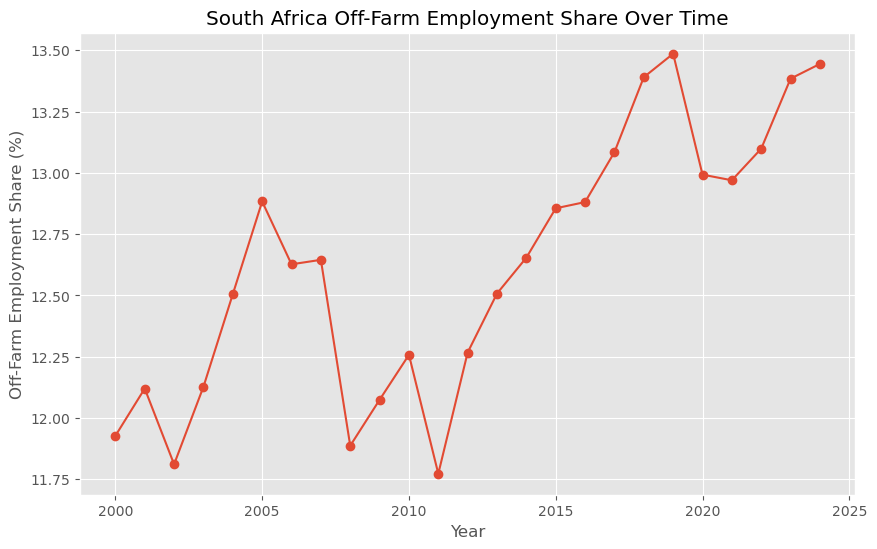

In [62]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.plot(
    employment_years,
    employment_values,
    marker="o"
)

plt.title("South Africa Off-Farm Employment Share Over Time")
plt.xlabel("Year")
plt.ylabel("Off-Farm Employment Share (%)")
plt.grid(True)

plt.show()

# Graph 2 — Total Freedom Score over Time

Interpretation: The line graph shows changes in South Africa's Total Freedom Score over time. It allows periods of increases and decreases in the freedom score to be identified. Overall, the graph shows that the freedom score changed over the period rather than remaining completely constant

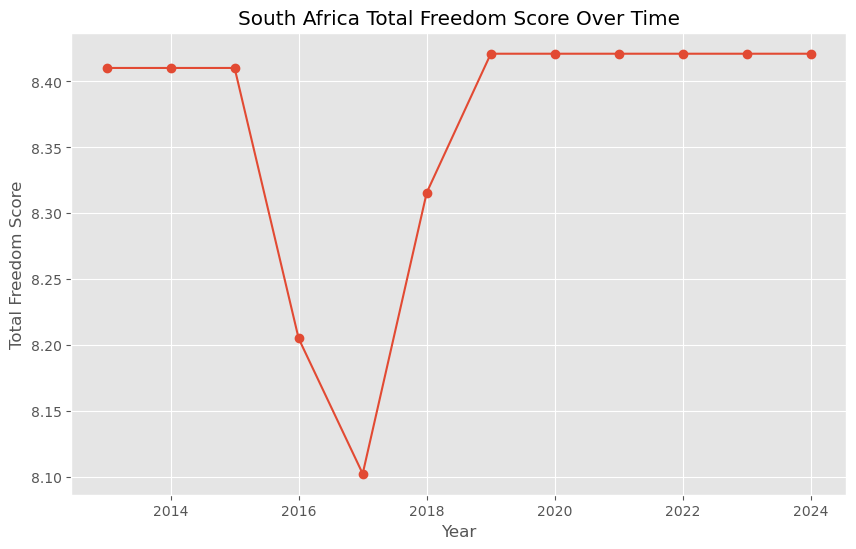

In [63]:
# Graph 2: Total Freedom Score from Question 2

plt.figure(figsize=(10, 6))

plt.plot(
    freedom_years,
    freedom_values,
    marker="o"
)

plt.title("South Africa Total Freedom Score Over Time")
plt.xlabel("Year")
plt.ylabel("Total Freedom Score")
plt.grid(True)

plt.show()

## Graph 3 — Employment and Freedom Comparison

Interpretation: This graph compares the Off-Farm Employment Share and Total Freedom Score across the same common years. It allows the two measures to be compared over time and shows whether their movements follow similar or different patterns. The graph provides a visual basis for examining the relationship between employment conditions and freedom in South Africa.

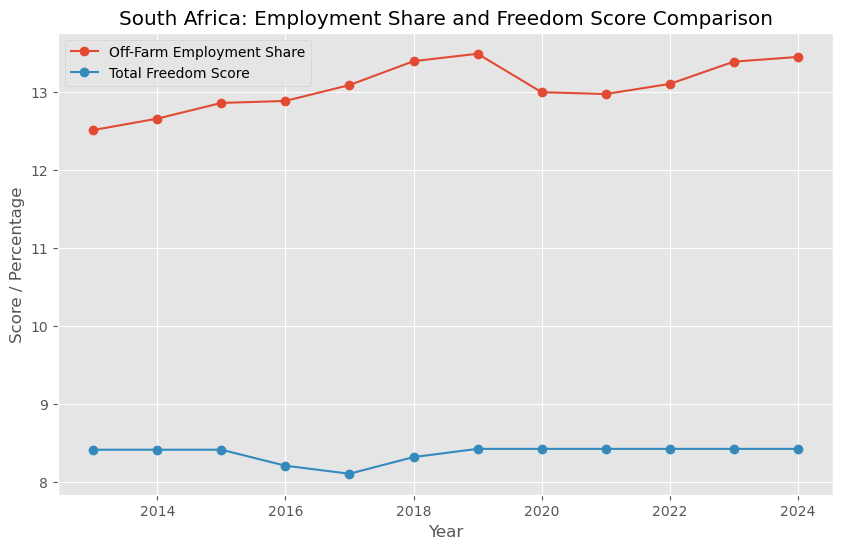

In [64]:


plt.figure(figsize=(10, 6))

plt.plot(
    common_years,
    employment_common,
    marker="o",
    label="Off-Farm Employment Share"
)

plt.plot(
    common_years,
    freedom_common,
    marker="o",
    label="Total Freedom Score"
)

plt.title("South Africa: Employment Share and Freedom Score Comparison")
plt.xlabel("Year")
plt.ylabel("Score / Percentage")
plt.legend()
plt.grid(True)

plt.show()

## Graph 4 — Employment vs Freedom Scatter Plot

Interpretation: The scatter plot shows the relationship between Off-Farm Employment Share and Total Freedom Score for the common years. The points show a negative relationship, meaning that higher Off-Farm Employment Share values tend to be associated with lower Total Freedom Score values in the data. The Question 2 correlation result of approximately -0.742 indicates a strong negative linear relationship. However, correlation does not by itself prove that changes in employment cause changes in freedom.

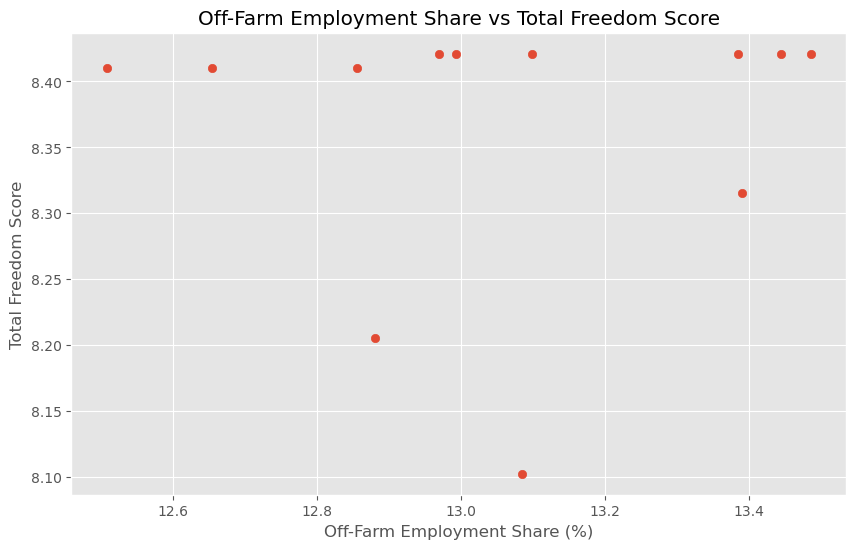

In [65]:


plt.figure(figsize=(10, 6))

plt.scatter(
    employment_common,
    freedom_common
)

plt.title("Off-Farm Employment Share vs Total Freedom Score")
plt.xlabel("Off-Farm Employment Share (%)")
plt.ylabel("Total Freedom Score")
plt.grid(True)

plt.show()

## Graph 5 — Box Plot

Interpretation: The box plot shows the distribution of the Off-Farm Employment Share values calculated in Question 2. The median represents the middle value, while the box shows the central spread of the observations. The plot also makes it possible to identify unusually high or low observations. Overall, the values are relatively concentrated, although the plot indicates some variation across the years.

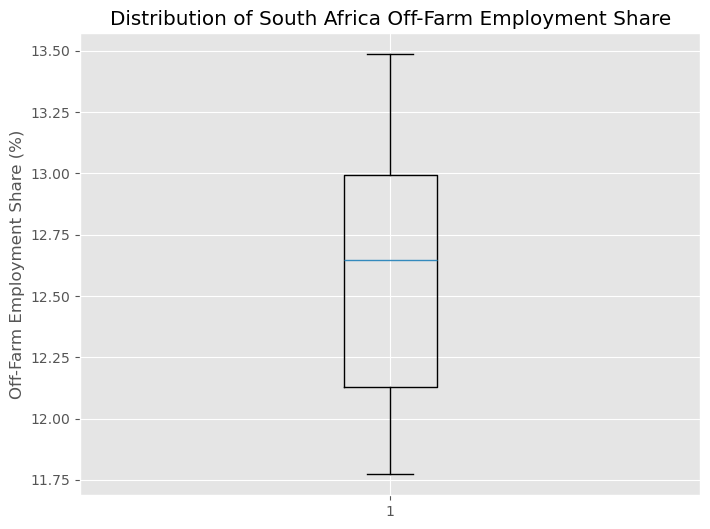

In [66]:



plt.figure(figsize=(8, 6))

plt.boxplot(
    employment_values
)

plt.title("Distribution of South Africa Off-Farm Employment Share")
plt.ylabel("Off-Farm Employment Share (%)")
plt.grid(True, axis="y")

plt.show()

## Question 3 Conclusion

Overall, the visualisations provide a clear view of the changes in South Africa's Off-Farm Employment Share and Total Freedom Score over time. The comparison of the common years and the scatter plot show a strong negative relationship between the two variables, consistent with the correlation of approximately -0.742 calculated in Question 2. However, this relationship should not be interpreted as evidence that one variable directly causes changes in the other

# Question 4: Database Integration

In [1]:
import pandas as pd
import numpy as np
import mysql.connector

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="******",
    database="ndta63_database"
)

cursor = connection.cursor()

print("MySQL connection successful!")

MySQL connection successful!


In [6]:
columns_to_keep = [
    "REF_AREA",
    "REF_AREA_LABEL",
    "INDICATOR",
    "INDICATOR_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE"
]

employment_db = employment_za[columns_to_keep].copy()
freedom_db = freedom_za[columns_to_keep].copy()

print("Employment database data:")
display(employment_db.head())

print("\nEmployment shape:", employment_db.shape)

print("\nFreedom database data:")
display(freedom_db.head())

print("\nFreedom shape:", freedom_db.shape)

Employment database data:


,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,TIME_PERIOD,OBS_VALUE
4212,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2000,11.927134
4213,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2001,12.119992
4214,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2002,11.811001
4215,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2003,12.127343
4216,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2004,12.505107



Employment shape: (25, 6)

Freedom database data:


,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,TIME_PERIOD,OBS_VALUE
45,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2024,2
241,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2023,2
437,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2022,2
633,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2021,2
829,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2020,2



Freedom shape: (560, 6)


In [10]:
if connection.is_connected():
    print("MySQL connection is active.")
else:
    print("MySQL connection is not active.")

MySQL connection is active.


## Create MySQL tables

In [11]:
create_employment_table = """
CREATE TABLE IF NOT EXISTS employment_data (
    id INT AUTO_INCREMENT PRIMARY KEY,
    ref_area VARCHAR(10),
    country VARCHAR(100),
    indicator VARCHAR(100),
    indicator_name TEXT,
    year INT,
    value DOUBLE
)
"""

create_freedom_table = """
CREATE TABLE IF NOT EXISTS freedom_data (
    id INT AUTO_INCREMENT PRIMARY KEY,
    ref_area VARCHAR(10),
    country VARCHAR(100),
    indicator VARCHAR(100),
    indicator_name TEXT,
    year INT,
    value DOUBLE
)
"""

cursor.execute(create_employment_table)
cursor.execute(create_freedom_table)

connection.commit()

print("Employment table created successfully!")
print("Freedom table created successfully!")

Employment table created successfully!
Freedom table created successfully!


In [12]:
cursor.execute("SHOW TABLES")

tables = cursor.fetchall()

print("Tables in ndta63_database:")

for table in tables:
    print(table[0])

Tables in ndta63_database:
employment_data
freedom_data


In [13]:
cursor.execute("DESCRIBE employment_data")

print("EMPLOYMENT TABLE STRUCTURE:")
for row in cursor.fetchall():
    print(row)

print("\n" + "=" * 80)


cursor.execute("DESCRIBE freedom_data")

print("FREEDOM TABLE STRUCTURE:")
for row in cursor.fetchall():
    print(row)

EMPLOYMENT TABLE STRUCTURE:
('id', 'int', 'NO', 'PRI', None, 'auto_increment')
('ref_area', 'varchar(10)', 'YES', '', None, '')
('country', 'varchar(100)', 'YES', '', None, '')
('indicator', 'varchar(100)', 'YES', '', None, '')
('indicator_name', 'text', 'YES', '', None, '')
('year', 'int', 'YES', '', None, '')
('value', 'double', 'YES', '', None, '')

FREEDOM TABLE STRUCTURE:
('id', 'int', 'NO', 'PRI', None, 'auto_increment')
('ref_area', 'varchar(10)', 'YES', '', None, '')
('country', 'varchar(100)', 'YES', '', None, '')
('indicator', 'varchar(100)', 'YES', '', None, '')
('indicator_name', 'text', 'YES', '', None, '')
('year', 'int', 'YES', '', None, '')
('value', 'double', 'YES', '', None, '')


## Prepare data for database integration

In [14]:
employment_insert = employment_db[
    [
        "REF_AREA",
        "REF_AREA_LABEL",
        "INDICATOR",
        "INDICATOR_LABEL",
        "TIME_PERIOD",
        "OBS_VALUE"
    ]
].copy()

employment_insert.columns = [
    "ref_area",
    "country",
    "indicator",
    "indicator_name",
    "year",
    "value"
]

print(employment_insert.head())
print("\nEmployment records ready for MySQL:", len(employment_insert))

     ref_area       country    indicator             indicator_name  year  \
4212      ZAF  South Africa  AG_SH_OFFFR  Off-Farm Employment Share  2000   
4213      ZAF  South Africa  AG_SH_OFFFR  Off-Farm Employment Share  2001   
4214      ZAF  South Africa  AG_SH_OFFFR  Off-Farm Employment Share  2002   
4215      ZAF  South Africa  AG_SH_OFFFR  Off-Farm Employment Share  2003   
4216      ZAF  South Africa  AG_SH_OFFFR  Off-Farm Employment Share  2004   

          value  
4212  11.927134  
4213  12.119992  
4214  11.811001  
4215  12.127343  
4216  12.505107  

Employment records ready for MySQL: 25


In [15]:
freedom_insert = freedom_db[
    [
        "REF_AREA",
        "REF_AREA_LABEL",
        "INDICATOR",
        "INDICATOR_LABEL",
        "TIME_PERIOD",
        "OBS_VALUE"
    ]
].copy()

freedom_insert.columns = [
    "ref_area",
    "country",
    "indicator",
    "indicator_name",
    "year",
    "value"
]

print(freedom_insert.head())
print("\nFreedom records ready for MySQL:", len(freedom_insert))

    ref_area       country  indicator  \
45       ZAF  South Africa  FH_FIW_F3   
241      ZAF  South Africa  FH_FIW_F3   
437      ZAF  South Africa  FH_FIW_F3   
633      ZAF  South Africa  FH_FIW_F3   
829      ZAF  South Africa  FH_FIW_F3   

                                        indicator_name  year  value  
45   Rule of Law: Is there protection from the ille...  2024    2.0  
241  Rule of Law: Is there protection from the ille...  2023    2.0  
437  Rule of Law: Is there protection from the ille...  2022    2.0  
633  Rule of Law: Is there protection from the ille...  2021    2.0  
829  Rule of Law: Is there protection from the ille...  2020    2.0  

Freedom records ready for MySQL: 537


## Insert data into MySQL

In [16]:
cursor.execute("DELETE FROM employment_data")
cursor.execute("DELETE FROM freedom_data")

connection.commit()

print("Database tables cleared successfully.")

Database tables cleared successfully.


In [17]:
employment_sql = """
INSERT INTO employment_data
(ref_area, country, indicator, indicator_name, year, value)
VALUES (%s, %s, %s, %s, %s, %s)
"""

employment_data = [
    tuple(row)
    for row in employment_insert.itertuples(index=False, name=None)
]

cursor.executemany(employment_sql, employment_data)

connection.commit()

print(f"{len(employment_data)} Employment records inserted successfully!")

25 Employment records inserted successfully!


In [18]:
freedom_sql = """
INSERT INTO freedom_data
(ref_area, country, indicator, indicator_name, year, value)
VALUES (%s, %s, %s, %s, %s, %s)
"""

freedom_data = [
    tuple(row)
    for row in freedom_insert.itertuples(index=False, name=None)
]

cursor.executemany(freedom_sql, freedom_data)

connection.commit()

print(f"{len(freedom_data)} Freedom records inserted successfully!")

537 Freedom records inserted successfully!


In [19]:
cursor.execute("""
SELECT *
FROM employment_data
LIMIT 10
""")

employment_results = cursor.fetchall()

print("First 10 Employment records from MySQL:")

for row in employment_results:
    print(row)

First 10 Employment records from MySQL:
(434, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2000, 11.927134)
(435, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2001, 12.119992)
(436, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2002, 11.811001)
(437, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2003, 12.127343)
(438, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2004, 12.505107)
(439, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2005, 12.883156)
(440, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2006, 12.626928)
(441, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2007, 12.645207)
(442, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2008, 11.886748)
(443, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2009, 12.074104)


In [20]:
cursor.execute("""
SELECT *
FROM freedom_data
LIMIT 10
""")

freedom_results = cursor.fetchall()

print("First 10 Freedom records from MySQL:")

for row in freedom_results:
    print(row)

First 10 Freedom records from MySQL:
(9130, 'ZAF', 'South Africa', 'FH_FIW_F3', 'Rule of Law: Is there protection from the illegitimate use of physical force and freedom from war and insurgencies?', 2024, 2.0)
(9131, 'ZAF', 'South Africa', 'FH_FIW_F3', 'Rule of Law: Is there protection from the illegitimate use of physical force and freedom from war and insurgencies?', 2023, 2.0)
(9132, 'ZAF', 'South Africa', 'FH_FIW_F3', 'Rule of Law: Is there protection from the illegitimate use of physical force and freedom from war and insurgencies?', 2022, 2.0)
(9133, 'ZAF', 'South Africa', 'FH_FIW_F3', 'Rule of Law: Is there protection from the illegitimate use of physical force and freedom from war and insurgencies?', 2021, 2.0)
(9134, 'ZAF', 'South Africa', 'FH_FIW_F3', 'Rule of Law: Is there protection from the illegitimate use of physical force and freedom from war and insurgencies?', 2020, 2.0)
(9135, 'ZAF', 'South Africa', 'FH_FIW_F3', 'Rule of Law: Is there protection from the illegitimate

In [21]:
cursor.execute("""
SELECT *
FROM employment_data
WHERE ref_area = 'ZAF'
""")

results = cursor.fetchall()

print("South African Employment records:")
for row in results:
    print(row)

print("\nTotal records returned:", len(results))

South African Employment records:
(434, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2000, 11.927134)
(435, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2001, 12.119992)
(436, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2002, 11.811001)
(437, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2003, 12.127343)
(438, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2004, 12.505107)
(439, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2005, 12.883156)
(440, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2006, 12.626928)
(441, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2007, 12.645207)
(442, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2008, 11.886748)
(443, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment Share', 2009, 12.074104)
(444, 'ZAF', 'South Africa', 'AG_SH_OFFFR', 'Off-Farm Employment S

In [22]:
cursor.execute("""
SELECT year, value
FROM employment_data
ORDER BY value DESC
""")

results = cursor.fetchall()

print("Employment values from highest to lowest:")

for row in results:
    print(row)

Employment values from highest to lowest:
(2019, 13.4860325)
(2024, 13.444483)
(2018, 13.390205)
(2023, 13.384285)
(2022, 13.098627)
(2017, 13.084312)
(2020, 12.992733)
(2021, 12.969736)
(2005, 12.883156)
(2016, 12.880799)
(2015, 12.855394)
(2014, 12.65408)
(2007, 12.645207)
(2006, 12.626928)
(2013, 12.507699)
(2004, 12.505107)
(2012, 12.267024)
(2010, 12.257574)
(2003, 12.127343)
(2001, 12.119992)
(2009, 12.074104)
(2000, 11.927134)
(2008, 11.886748)
(2002, 11.811001)
(2011, 11.772565)


In [23]:
cursor.execute("""
SELECT year, AVG(value) AS average_freedom_score
FROM freedom_data
GROUP BY year
ORDER BY year
""")

results = cursor.fetchall()

print("Average Freedom score by year:")

for row in results:
    print(row)

Average Freedom score by year:
(2013, 8.41025641025641)
(2014, 8.41025641025641)
(2015, 8.41025641025641)
(2016, 8.205128205128204)
(2017, 8.102564102564102)
(2018, 8.31578947368421)
(2019, 8.421052631578947)
(2020, 8.421052631578947)
(2021, 8.421052631578947)
(2022, 8.421052631578947)
(2023, 8.421052631578947)
(2024, 8.421052631578947)
(2025, 8.631578947368421)
(2026, 8.631578947368421)


In [24]:
cursor.execute("""
SELECT
    MIN(value) AS minimum_value,
    MAX(value) AS maximum_value,
    AVG(value) AS average_value
FROM freedom_data
""")

result = cursor.fetchone()

print("Freedom data statistics:")
print("Minimum:", result[0])
print("Maximum:", result[1])
print("Average:", result[2])

Freedom data statistics:
Minimum: 0.0
Maximum: 81.0
Average: 8.402234636871508


In [25]:
cursor.execute("""
SELECT indicator, COUNT(*) AS record_count
FROM freedom_data
GROUP BY indicator
ORDER BY record_count DESC
""")

results = cursor.fetchall()

print("Records per Freedom indicator:")

for row in results:
    print(row)

Records per Freedom indicator:
('FH_FIW_F3', 14)
('FH_FIW_F4', 14)
('FH_FIW_F', 14)
('FH_FIW_G1', 14)
('FH_FIW_G2', 14)
('FH_FIW_G3', 14)
('FH_FIW_G4', 14)
('FH_FIW_G', 14)
('FH_FIW_CL', 14)
('FH_FIW_TOTAL', 14)
('FH_FIW_D2', 14)
('FH_FIW_D3', 14)
('FH_FIW_D4', 14)
('FH_FIW_D', 14)
('FH_FIW_E1', 14)
('FH_FIW_E2', 14)
('FH_FIW_E3', 14)
('FH_FIW_E', 14)
('FH_FIW_F1', 14)
('FH_FIW_F2', 14)
('FH_FIW_B4', 14)
('FH_FIW_B', 14)
('FH_FIW_C1', 14)
('FH_FIW_C2', 14)
('FH_FIW_C3', 14)
('FH_FIW_C', 14)
('FH_FIW_ADD_Q', 14)
('FH_FIW_PR', 14)
('FH_FIW_D1', 14)
('FH_FIW_PR_RATING', 14)
('FH_FIW_CL_RATING', 14)
('FH_FIW_A1', 14)
('FH_FIW_A2', 14)
('FH_FIW_A3', 14)
('FH_FIW_A', 14)
('FH_FIW_B1', 14)
('FH_FIW_B2', 14)
('FH_FIW_B3', 14)
('FH_FIW_ADD_A', 5)


In [26]:
query = """
SELECT
    ref_area,
    country,
    indicator,
    indicator_name,
    year,
    value
FROM freedom_data
"""

freedom_from_mysql = pd.read_sql(query, connection)

print("Freedom data retrieved from MySQL:")
display(freedom_from_mysql.head())

print("\nShape:", freedom_from_mysql.shape)

Freedom data retrieved from MySQL:


C:\Users\Admin\AppData\Local\Temp\ipykernel_43988\4079818570.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  freedom_from_mysql = pd.read_sql(query, connection)


,ref_area,country,indicator,indicator_name,year,value
0,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2024,2.0
1,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2023,2.0
2,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2022,2.0
3,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2021,2.0
4,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2020,2.0



Shape: (537, 6)


In [27]:
query = """
SELECT
    ref_area,
    country,
    indicator,
    indicator_name,
    year,
    value
FROM employment_data
"""

employment_from_mysql = pd.read_sql(query, connection)

print("Employment data retrieved from MySQL:")
display(employment_from_mysql.head())

print("\nShape:", employment_from_mysql.shape)

Employment data retrieved from MySQL:


C:\Users\Admin\AppData\Local\Temp\ipykernel_43988\841933358.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  employment_from_mysql = pd.read_sql(query, connection)


,ref_area,country,indicator,indicator_name,year,value
0,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2000,11.927134
1,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2001,12.119992
2,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2002,11.811001
3,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2003,12.127343
4,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2004,12.505107



Shape: (25, 6)


In [28]:
cursor.execute("SELECT COUNT(*) FROM employment_data")
employment_total = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) FROM freedom_data")
freedom_total = cursor.fetchone()[0]

print("FINAL DATABASE CHECK")
print("====================")
print("Employment records:", employment_total)
print("Freedom records:", freedom_total)

if employment_total == 25 and freedom_total == 537:
    print("\nDatabase integration verified successfully!")
else:
    print("\nRecord counts do not match the expected totals.")

FINAL DATABASE CHECK
Employment records: 25
Freedom records: 537

Database integration verified successfully!


In [29]:
print("EMPLOYMENT TABLE SCHEMA")
print("=======================")

cursor.execute("DESCRIBE employment_data")

for row in cursor.fetchall():
    print(row)

print("\nFREEDOM TABLE SCHEMA")
print("====================")

cursor.execute("DESCRIBE freedom_data")

for row in cursor.fetchall():
    print(row)

EMPLOYMENT TABLE SCHEMA
('id', 'int', 'NO', 'PRI', None, 'auto_increment')
('ref_area', 'varchar(10)', 'YES', '', None, '')
('country', 'varchar(100)', 'YES', '', None, '')
('indicator', 'varchar(100)', 'YES', '', None, '')
('indicator_name', 'text', 'YES', '', None, '')
('year', 'int', 'YES', '', None, '')
('value', 'double', 'YES', '', None, '')

FREEDOM TABLE SCHEMA
('id', 'int', 'NO', 'PRI', None, 'auto_increment')
('ref_area', 'varchar(10)', 'YES', '', None, '')
('country', 'varchar(100)', 'YES', '', None, '')
('indicator', 'varchar(100)', 'YES', '', None, '')
('indicator_name', 'text', 'YES', '', None, '')
('year', 'int', 'YES', '', None, '')
('value', 'double', 'YES', '', None, '')


## Database operations

In [30]:
cursor.execute("""
SELECT id, year, value
FROM employment_data
ORDER BY id
LIMIT 1
""")

record = cursor.fetchone()

print("Original record:")
print(record)

record_id = record[0]
original_value = record[2]

temporary_value = original_value + 0.001

cursor.execute("""
UPDATE employment_data
SET value = %s
WHERE id = %s
""", (temporary_value, record_id))

connection.commit()

print("Updated value:", temporary_value)


cursor.execute("""
UPDATE employment_data
SET value = %s
WHERE id = %s
""", (original_value, record_id))

connection.commit()

print("Original value restored:", original_value)

Original record:
(434, 2000, 11.927134)
Updated value: 11.928134
Original value restored: 11.927134


In [31]:
cursor.execute("""
INSERT INTO employment_data
(ref_area, country, indicator, indicator_name, year, value)
VALUES (%s, %s, %s, %s, %s, %s)
""", (
    "TEST",
    "Test Country",
    "TEST_INDICATOR",
    "Temporary Delete Test",
    9999,
    0.0
))

connection.commit()

temporary_id = cursor.lastrowid

print("Temporary record created.")
print("Temporary record ID:", temporary_id)

cursor.execute("""
DELETE FROM employment_data
WHERE id = %s
""", (temporary_id,))

connection.commit()

print("Temporary record deleted successfully.")

cursor.execute("""
SELECT COUNT(*)
FROM employment_data
WHERE id = %s
""", (temporary_id,))

remaining = cursor.fetchone()[0]

print("Remaining temporary records:", remaining)

Temporary record created.
Temporary record ID: 459
Temporary record deleted successfully.
Remaining temporary records: 0


In [32]:
cursor.execute("SELECT COUNT(*) FROM employment_data")
employment_total = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) FROM freedom_data")
freedom_total = cursor.fetchone()[0]

print("FINAL DATABASE CHECK")
print("====================")
print("Employment records:", employment_total)
print("Freedom records:", freedom_total)

if employment_total == 25 and freedom_total == 537:
    print("\nDatabase data is complete and correct!")
else:
    print("\nWARNING: Record counts do not match expected totals.")

FINAL DATABASE CHECK
Employment records: 25
Freedom records: 537

Database data is complete and correct!


## Retrieve data from MySQL

In [33]:
employment_from_mysql = pd.read_sql("""
SELECT
    ref_area,
    country,
    indicator,
    indicator_name,
    year,
    value
FROM employment_data
""", connection)

freedom_from_mysql = pd.read_sql("""
SELECT
    ref_area,
    country,
    indicator,
    indicator_name,
    year,
    value
FROM freedom_data
""", connection)

print("Employment data retrieved from MySQL:")
display(employment_from_mysql.head())

print("\nFreedom data retrieved from MySQL:")
display(freedom_from_mysql.head())

print("\nEmployment shape:", employment_from_mysql.shape)
print("Freedom shape:", freedom_from_mysql.shape)

Employment data retrieved from MySQL:


C:\Users\Admin\AppData\Local\Temp\ipykernel_43988\1153801331.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  employment_from_mysql = pd.read_sql("""
C:\Users\Admin\AppData\Local\Temp\ipykernel_43988\1153801331.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  freedom_from_mysql = pd.read_sql("""


,ref_area,country,indicator,indicator_name,year,value
0,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2000,11.927134
1,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2001,12.119992
2,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2002,11.811001
3,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2003,12.127343
4,ZAF,South Africa,AG_SH_OFFFR,Off-Farm Employment Share,2004,12.505107



Freedom data retrieved from MySQL:


,ref_area,country,indicator,indicator_name,year,value
0,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2024,2.0
1,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2023,2.0
2,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2022,2.0
3,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2021,2.0
4,ZAF,South Africa,FH_FIW_F3,Rule of Law: Is there protection from the ille...,2020,2.0



Employment shape: (25, 6)
Freedom shape: (537, 6)


## Export database data

In [34]:
employment_from_mysql.to_csv(
    r"C:\Users\Admin\Downloads\Employment_From_MySQL_Final.csv",
    index=False
)

freedom_from_mysql.to_csv(
    r"C:\Users\Admin\Downloads\Freedom_From_MySQL_Final.csv",
    index=False
)

print("Employment CSV exported successfully.")
print("Freedom CSV exported successfully.")

print("\nEmployment rows exported:", len(employment_from_mysql))
print("Freedom rows exported:", len(freedom_from_mysql))

Employment CSV exported successfully.
Freedom CSV exported successfully.

Employment rows exported: 25
Freedom rows exported: 537


In [35]:
employment_check = pd.read_csv(
    r"C:\Users\Admin\Downloads\Employment_From_MySQL_Final.csv"
)

freedom_check = pd.read_csv(
    r"C:\Users\Admin\Downloads\Freedom_From_MySQL_Final.csv"
)

print("FINAL CSV CHECK")
print("================")
print("Employment file shape:", employment_check.shape)
print("Freedom file shape:", freedom_check.shape)

print("\nEmployment columns:")
print(employment_check.columns.tolist())

print("\nFreedom columns:")
print(freedom_check.columns.tolist())

FINAL CSV CHECK
Employment file shape: (25, 6)
Freedom file shape: (537, 6)

Employment columns:
['ref_area', 'country', 'indicator', 'indicator_name', 'year', 'value']

Freedom columns:
['ref_area', 'country', 'indicator', 'indicator_name', 'year', 'value']


## Conclusion

The prepared South Africa datasets were integrated into MySQL successfully. The database tables were created, populated, queried, updated, and verified, and the resulting data was retrieved and exported.

## Question 5: Data Cleaning, Conditional Formatting, Charts and Findings

This section contains only my contribution: cleaning and transforming the data, applying conditional formatting, creating charts, and summarising the findings.

It builds directly on the South Africa data retrieved from MySQL and verified in Question 4 (`employment_check` and `freedom_check`), so no data is reloaded from CSV files here.

### 5.1 Clean and Transform the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the South Africa data retrieved from MySQL and verified at the end of
# Question 4 (employment_check / freedom_check), instead of re-reading the
# original CSV files. This keeps Question 5 compatible with the rest of the
# notebook and avoids depending on a local "data" folder that doesn't exist
# in this project.
employment = employment_check.copy()
freedom = freedom_check.copy()

# Clean column names
employment.columns = employment.columns.str.strip()
freedom.columns = freedom.columns.str.strip()

# Convert important columns to numeric
# (the MySQL export uses lowercase "year" and "value" column names,
# not the original "TIME_PERIOD" / "OBS_VALUE" names)
for df in [employment, freedom]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Remove missing values and duplicates
employment = employment.dropna(subset=["year", "value"]).drop_duplicates()
freedom = freedom.dropna(subset=["year", "value"]).drop_duplicates()

# Keep South Africa (already filtered to ZAF via the SQL query in Question 4,
# but this is kept as a safeguard in case the source data changes)
employment_za = employment[employment["ref_area"] == "ZAF"].copy()
freedom_za = freedom[freedom["ref_area"] == "ZAF"].copy()

# Employment value by year
employment_yearly = (
    employment_za.groupby("year", as_index=False)["value"]
    .mean()
    .rename(columns={
        "year": "Year",
        "value": "Employment Share (%)"
    })
)

# Select Total Freedom Score
freedom_total = freedom_za[
    freedom_za["indicator_name"].astype(str).str.contains(
        "Total Freedom Score", case=False, na=False
    )
]

freedom_source = freedom_total if not freedom_total.empty else freedom_za

freedom_yearly = (
    freedom_source.groupby("year", as_index=False)["value"]
    .mean()
    .rename(columns={
        "year": "Year",
        "value": "Freedom Score"
    })
)

# Combine datasets using common years
analysis = pd.merge(
    employment_yearly,
    freedom_yearly,
    on="Year",
    how="inner"
).sort_values("Year").reset_index(drop=True)

# Transformations
analysis["Employment Change"] = analysis["Employment Share (%)"].diff()
analysis["Freedom Change"] = analysis["Freedom Score"].diff()

analysis["Employment Growth (%)"] = (
    analysis["Employment Share (%)"].pct_change() * 100
)

analysis["Freedom Growth (%)"] = (
    analysis["Freedom Score"].pct_change() * 100
)

analysis["Employment Z-Score"] = (
    (analysis["Employment Share (%)"] -
     analysis["Employment Share (%)"].mean())
    / analysis["Employment Share (%)"].std()
)

analysis["Freedom Z-Score"] = (
    (analysis["Freedom Score"] -
     analysis["Freedom Score"].mean())
    / analysis["Freedom Score"].std()
)

analysis = analysis.round(3)

display(analysis)


### 5.2 Apply Conditional Formatting

In [ ]:
from openpyxl import load_workbook
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

excel_file = "Question_5_Data_Analysis.xlsx"

# Export cleaned data
analysis.to_excel(
    excel_file,
    sheet_name="Cleaned Data",
    index=False
)

# Open workbook and apply formatting
workbook = load_workbook(excel_file)
worksheet = workbook["Cleaned Data"]

for cell in worksheet[1]:
    cell.font = Font(bold=True)

# Red = low, yellow = middle, green = high
# Apply to every numeric column (everything except column A, "Year"),
# worked out dynamically so it stays correct even if columns are added
last_column_letter = get_column_letter(worksheet.max_column)
for col_index in range(2, worksheet.max_column + 1):
    column = get_column_letter(col_index)
    worksheet.conditional_formatting.add(
        f"{column}2:{column}{worksheet.max_row}",
        ColorScaleRule(
            start_type="min",
            start_color="F8696B",
            mid_type="percentile",
            mid_value=50,
            mid_color="FFEB84",
            end_type="max",
            end_color="63BE7B"
        )
    )

worksheet.freeze_panes = "A2"
workbook.save(excel_file)

print("Excel file created successfully:", excel_file)


### 5.3 Create Charts

In [ ]:
# Chart 1: Employment Share over Time
plt.figure(figsize=(10, 5))
plt.plot(
    analysis["Year"],
    analysis["Employment Share (%)"],
    marker="o"
)
plt.title("South Africa Off-Farm Employment Share Over Time")
plt.xlabel("Year")
plt.ylabel("Employment Share (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Chart 2: Freedom Score over Time
plt.figure(figsize=(10, 5))
plt.plot(
    analysis["Year"],
    analysis["Freedom Score"],
    marker="o"
)
plt.title("South Africa Total Freedom Score Over Time")
plt.xlabel("Year")
plt.ylabel("Freedom Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Chart 3: Employment Share vs Freedom Score
correlation = analysis["Employment Share (%)"].corr(analysis["Freedom Score"])

plt.figure(figsize=(8, 6))
plt.scatter(
    analysis["Employment Share (%)"],
    analysis["Freedom Score"]
)
plt.title(f"Employment Share vs Freedom Score (r = {correlation:.3f})")
plt.xlabel("Employment Share (%)")
plt.ylabel("Freedom Score")
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.4 Summarise the Findings

In [ ]:
highest_employment = analysis.loc[analysis["Employment Share (%)"].idxmax()]
lowest_employment = analysis.loc[analysis["Employment Share (%)"].idxmin()]
highest_freedom = analysis.loc[analysis["Freedom Score"].idxmax()]
lowest_freedom = analysis.loc[analysis["Freedom Score"].idxmin()]

if correlation <= -0.7:
    relationship = "strong negative relationship"
elif correlation <= -0.3:
    relationship = "moderate negative relationship"
elif correlation < 0.3:
    relationship = "weak or little linear relationship"
elif correlation < 0.7:
    relationship = "moderate positive relationship"
else:
    relationship = "strong positive relationship"

print("SUMMARY OF FINDINGS")
print("=" * 50)
print(f"Years analysed: {int(analysis['Year'].min())}-{int(analysis['Year'].max())}")
print(f"Average employment share: {analysis['Employment Share (%)'].mean():.2f}%")
print(f"Average freedom score: {analysis['Freedom Score'].mean():.2f}")
print(
    f"Highest employment share: "
    f"{highest_employment['Employment Share (%)']:.2f}% "
    f"in {int(highest_employment['Year'])}"
)
print(
    f"Lowest employment share: "
    f"{lowest_employment['Employment Share (%)']:.2f}% "
    f"in {int(lowest_employment['Year'])}"
)
print(
    f"Highest freedom score: "
    f"{highest_freedom['Freedom Score']:.2f} "
    f"in {int(highest_freedom['Year'])}"
)
print(
    f"Lowest freedom score: "
    f"{lowest_freedom['Freedom Score']:.2f} "
    f"in {int(lowest_freedom['Year'])}"
)
print(f"Pearson correlation: {correlation:.3f}")
print(f"Interpretation: {relationship}.")
print("Correlation shows association; it does not prove causation.")


### Question 5 Conclusion

The South Africa employment and freedom data retrieved from MySQL in Question 4 were cleaned, transformed and combined using common years. Missing observations and duplicates were removed, numerical fields were converted to the correct types, and change, growth and Z-score measures were calculated. Conditional formatting was applied to the Excel output, and three charts were created to show trends and the relationship between the variables.